# 03 — Model Results: Loss Curves, Feature Importance, Actual vs Predicted, Model Comparison

Spec: `specs/003-complete-forecasting-submission/spec.md` FR-30–FR-34; model comparison table from
`src/backtest.py` (T008).

This notebook **displays already-generated artifacts**; it does not recompute SHAP, metrics, or
figures inline (spec 003 T012 constraint). Figures were produced by `src/report_assets.py` (T011)
and saved to `outputs/figures/`. The model comparison table was produced by `src/backtest.py`
(T008) and saved to `outputs/metrics/model_comparison.csv`; it is loaded here as a plain
`pandas.read_csv`, not recomputed.

In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from src...` imports resolve regardless of the
# notebook's working directory (nbconvert executes with cwd = notebooks/).
_repo_root = Path.cwd()
if not (_repo_root / "src").exists():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import os
os.chdir(_repo_root)

import pandas as pd
from IPython.display import Image, display

from src.backtest import OUTPUT_PATH as COMPARISON_PATH

FIGURES_DIR = Path("outputs/figures")


## 1. LightGBM / XGBoost loss (evaluation) curves

Generated by `src/report_assets.py::fig_loss_curves` from the Fold 1 LightGBM/XGBoost eval
histories (FR-31), saved to `outputs/figures/loss_curves.png`.

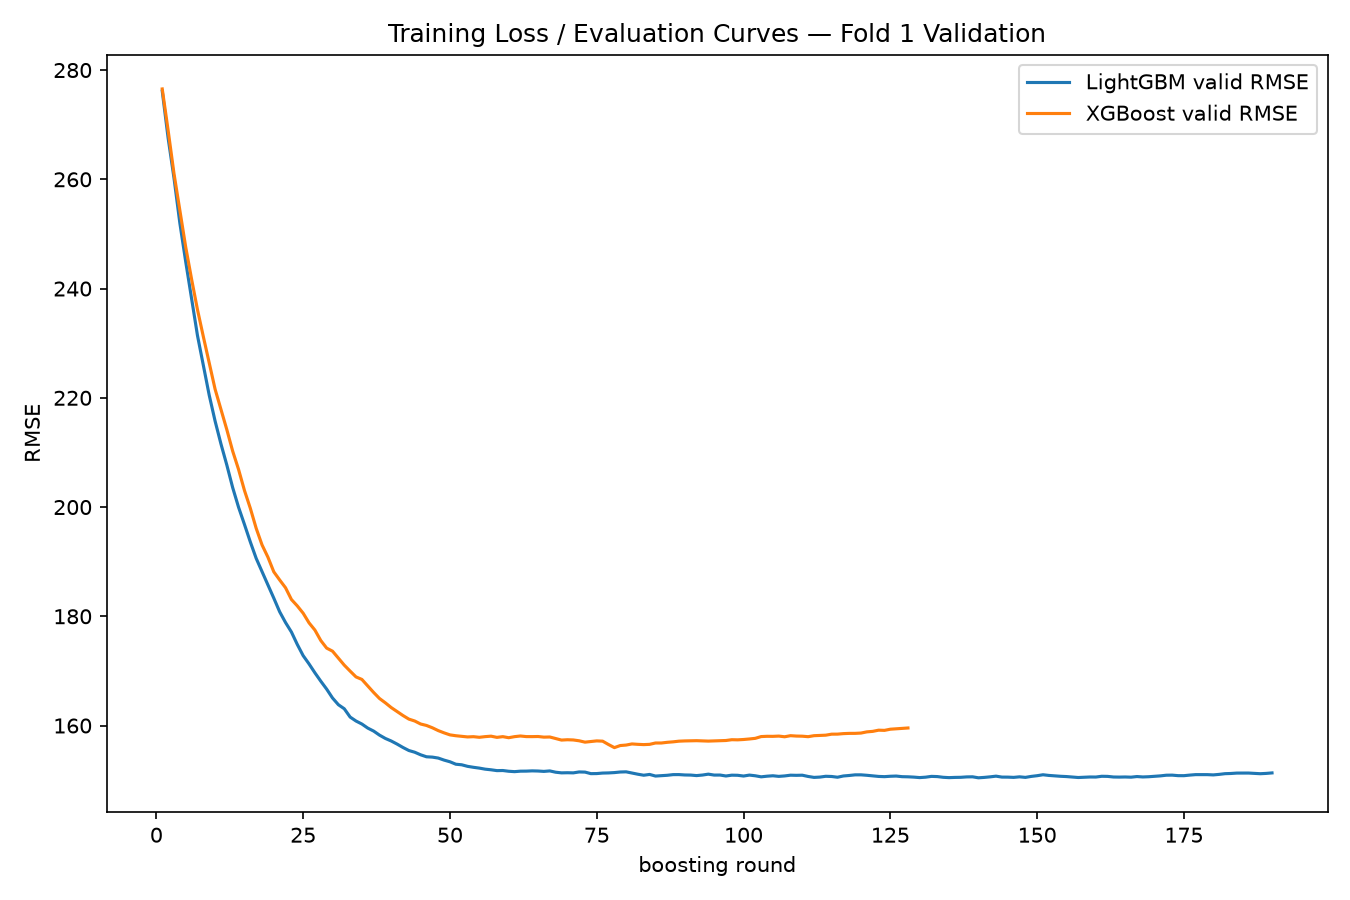

In [2]:
display(Image(filename=str(FIGURES_DIR / "loss_curves.png")))


## 2. SHAP feature importance (final LightGBM model)

Generated by `src/report_assets.py::fig_shap_importance` on a deterministic 300-row sample of the
Fold 1 validation set (FR-30); a gain/permutation-importance fallback is documented in
`src/report_assets.py` for the case SHAP is too slow, but was not needed for this run (SHAP
completed in ~0.1s). Saved to `outputs/figures/feature_importance.png`.

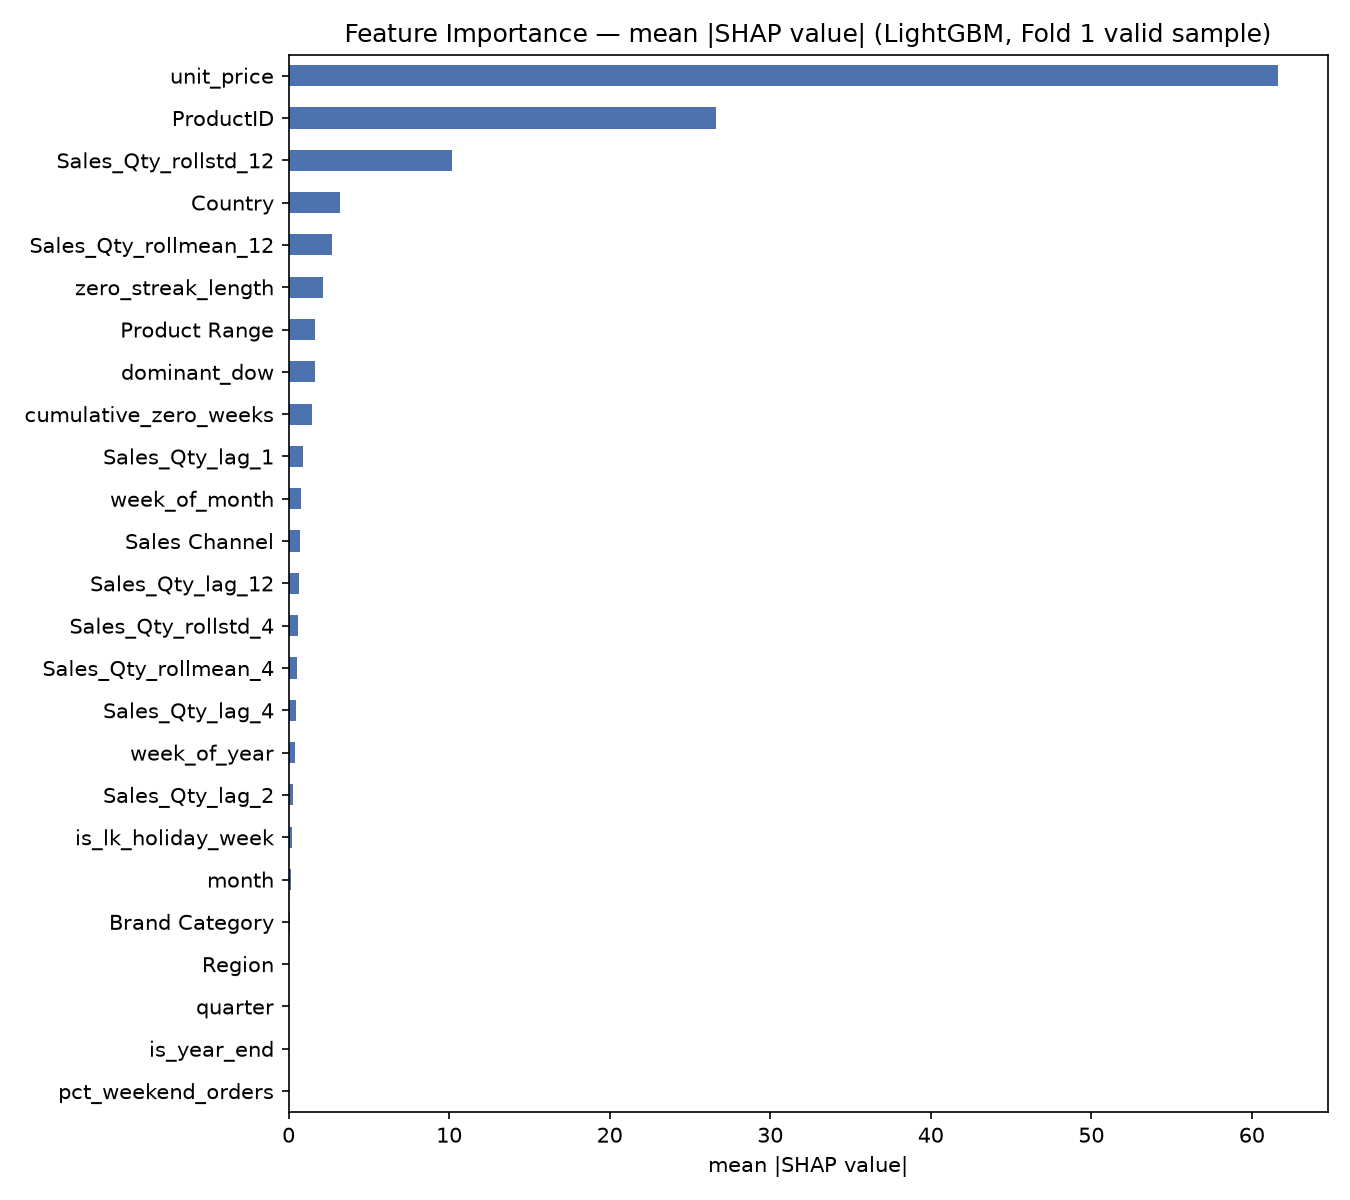

In [3]:
display(Image(filename=str(FIGURES_DIR / "feature_importance.png")))


## 3. Actual vs predicted (high-volume and sparse products)

Generated by `src/report_assets.py::fig_actual_vs_predicted` (FR-32), covering at least one
high-volume and one sparse product. Saved to `outputs/figures/actual_vs_predicted.png`.

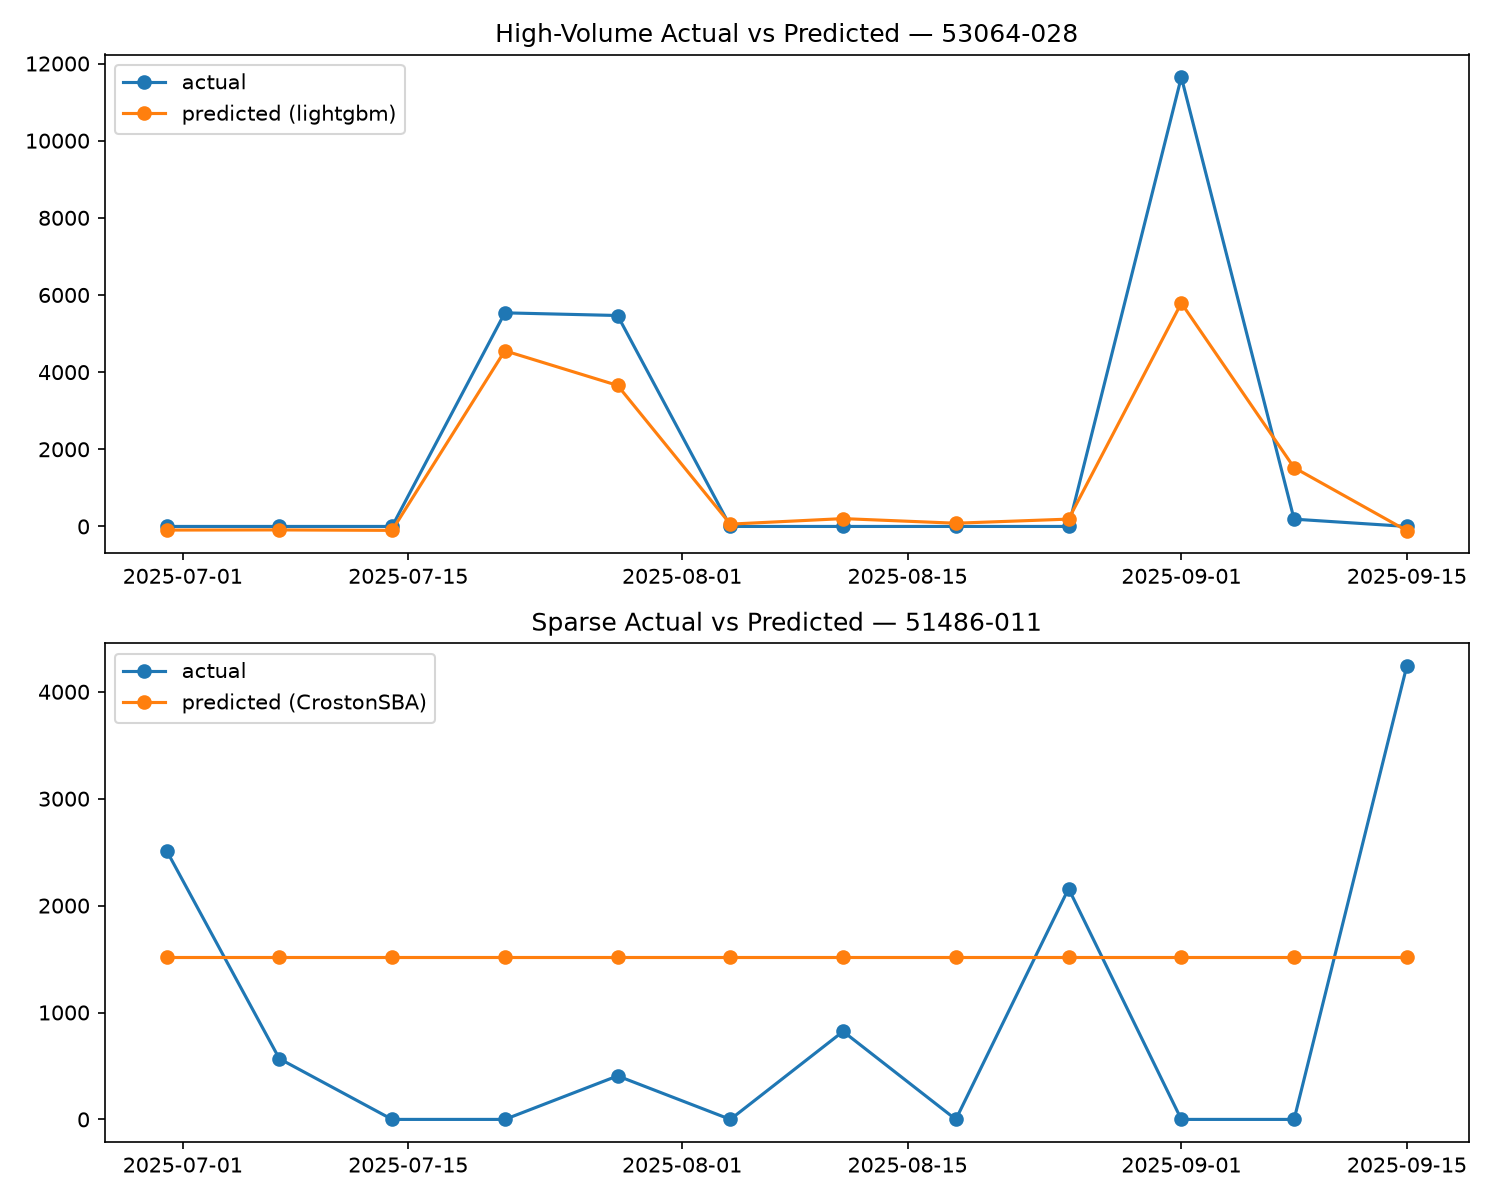

In [4]:
display(Image(filename=str(FIGURES_DIR / "actual_vs_predicted.png")))


## 4. Model comparison table

Loaded directly from `outputs/metrics/model_comparison.csv`, produced by `src/backtest.py` (T008)
using `src/metrics.py` (T002) scoring functions on the T005/T006 validation predictions. High-volume
rows report RMSE/MAE; sparse rows report WMAPE/MASE; each tier has at least one `is_baseline=True`
row (AC-6).

In [5]:
comparison = pd.read_csv(COMPARISON_PATH)
comparison


,tier,model,is_baseline,rmse,mae,wmape,mase,train_seconds,inference_seconds
0,high_volume,lightgbm,False,150.433073,15.887949,NaN,NaN,1.439151,0.076476
1,high_volume,seasonal_naive,True,360.582019,54.834973,NaN,NaN,0.000000,0.002678
2,high_volume,xgboost,False,155.958547,15.581272,NaN,NaN,1.387919,0.036962
3,sparse,CrostonClassic,False,NaN,NaN,21.365578,36.109609,2.079166,2.079166
4,sparse,CrostonSBA,False,NaN,NaN,20.344390,34.436478,2.079166,2.079166
5,sparse,Naive,True,NaN,NaN,2.008995,2.953918,2.079166,2.079166
6,sparse,TSB,False,NaN,NaN,3.144757,3.111856,2.079166,2.079166


### Honest baseline check (FR-23/EC-6)

Per-tier: does the best non-baseline model beat the baseline row on its tier's primary metric
(RMSE for high-volume, WMAPE for sparse)? This cell only reads/compares numbers already present in
`comparison` above — no metric is recomputed.

In [6]:
for tier, primary_metric in [("high_volume", "rmse"), ("sparse", "wmape")]:
    tier_rows = comparison[comparison["tier"] == tier]
    baseline = tier_rows[tier_rows["is_baseline"]]
    challengers = tier_rows[~tier_rows["is_baseline"]]
    baseline_value = baseline[primary_metric].iloc[0]
    best_challenger = challengers.loc[challengers[primary_metric].idxmin()]
    beats_baseline = best_challenger[primary_metric] < baseline_value
    print(
        f"[{tier}] baseline {primary_metric}={baseline_value:.3f} ({baseline['model'].iloc[0]}) "
        f"vs. best non-baseline {best_challenger[primary_metric]:.3f} ({best_challenger['model']}) "
        f"-> best non-baseline beats baseline: {beats_baseline}"
    )


[high_volume] baseline rmse=360.582 (seasonal_naive) vs. best non-baseline 150.433 (lightgbm) -> best non-baseline beats baseline: True
[sparse] baseline wmape=2.009 (Naive) vs. best non-baseline 3.145 (TSB) -> best non-baseline beats baseline: False
